<a href="https://colab.research.google.com/github/memadan122/Android-/blob/main/COMP6011_Task2_PoC_MadanBastakoti_22142243.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP6011 — Research Task 2
## Suicide Risk Detection: Llama 3.1 8B Instant vs Llama 3.3 70B Versatile (via Groq Free API)

**Unit:** Advanced AI Research Topics  
**Dataset:** Human-AI-Dialogue-Suicide-Risk-Dataset (paraphrased, 10 cases)  
**Citation:** Chen, X., Li, Q., Jiang, Y., Liu, M., Yang, L., Jing, X., Wei, Z., & Cao, L. (2026). Human-AI-Dialogue-Suicide-Risk-Dataset [Data set]. Zenodo. https://doi.org/10.5281/zenodo.18684594
#### Student Name, ID: Madan Bastakoti, 22142243
### Architecture
| Approach | Model | Access | Method |
|---|---|---|---|
| **Model A** | `llama-3.1-8b-instant` (Llama 3.1 8B Instant) | Groq Free API | Zero-shot prompt classification |
| **Model B** | `llama-3.3-70b-versatile` (Llama 3.3 70B Versatile) | Groq Free API | Zero-shot prompt classification |

> **Note:** Both models run **completely free** via [Groq's free-tier API](https://console.groq.com)
> Llama 3.1 8B Instant is a compact, fast open-source model ideal for latency-sensitive screening.  
> Llama 3.3 70B Versatile is Meta's latest flagship open-source model — significantly stronger reasoning, used here as the high-performance clinical baseline.

### Risk Categories (5-class)
- **attempt** — discussion of past attempts, imminent plans, or active self-harm
- **behavior** — actions/preparations suggesting increased intent
- **ideation** — thoughts of dying without a specific, immediate plan
- **indicator** — signs of severe distress (hopelessness, burden) without explicit ideation
- **safe** — no immediate suicide risk

---
**Content Warning:** This notebook processes sensitive mental health dialogue. Handle with clinical care.

## Cell 1 — Install Dependencies

In [ ]:
# Install required packages
!pip install -q groq
!pip install -q pandas scikit-learn matplotlib seaborn
print("✅ Dependencies installed.")

✅ Dependencies installed.


## Cell 2 — Groq API Key Setup

> **Action required:**  
> 1. Create a **free** account at https://console.groq.com  
> 2. Generate an API key under *API Keys*  
> 3. In Colab, go to **Runtime → Manage Secrets** → add a secret named `GROQ_API_KEY` with your key  
>  
> no paid subscription needed.

## CRITICAL: Data Privacy & Deployment Constraints

### Why Real Patient Data Must NEVER Be Sent to a Public API

This proof-of-concept uses **Groq's public cloud inference API**. This is acceptable for research and PoC purposes **only** because:

1. **All 10 cases used here are AI-paraphrased synthetic dialogues** — not real patient conversations. No identifiable health information is transmitted.
2. The original dataset (Chen et al., 2026) is a publicly released research dataset, not clinical records.

### ❌ What You Must NEVER Do in a Real Deployment

> **Sending real patient conversations to any public AI service (Groq, OpenAI/ChatGPT, Anthropic, Google Gemini, etc.) would constitute a serious breach of:**
> - The *Privacy Act 1988* (Cth) — health information is sensitive personal information
> - The *My Health Records Act 2012* (Cth)
> - The Notifiable Data Breaches scheme
> - Ethical obligations under AHPRA and applicable mental health service standards

This means **you cannot use the Groq API as implemented here with real patient data** — even if the API claims data is not stored.

### ✅ Required Architecture for Real Clinical Deployment

For any production clinical system handling real patient dialogue, the model **must run locally or on sovereign infrastructure**:

| Deployment Option | Suitable for real patients? | Notes |
|---|---|---|
| Groq public API (as used here) | ❌ PoC/research only | Data leaves Australian jurisdiction |
| OpenAI / ChatGPT API | ❌ Never | Public US cloud, no health data |
| Self-hosted Llama 3.1 8B (local GPU) | ✅ Yes | ~16 GB VRAM, QLoRA quantisation |
| Australian-sovereign cloud (e.g., AUCloud) | ✅ Yes | Requires data residency agreement |
| Ollama on hospital on-premise server | ✅ Yes | Fully air-gapped option |

### Minimum Technical Safeguards for Production

- AES-256 encryption at rest; TLS 1.3 in transit
- No dialogue text logged beyond the immediate inference session
- Formal Data Management Plan prior to any patient data use
- Ethics approval from the relevant institutional review board
- All output reviewed by a licensed mental health clinician before any action is taken

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "groq"], check=True)

from groq import Groq
from google.colab import userdata

# ── Colab Secrets (recommended) ───────────────────────────────────────
# 1. Click the 🔑 KEY icon in the LEFT sidebar of Colab
# 2. Click "Add new secret"
# 3. Name:  GROQ_API_KEY
# 4. Value: paste your key from https://console.groq.com → API Keys
# 5. Toggle ON "Notebook access"
# 6. Run this cell

groq_api_key = userdata.get('GROQ_API_KEY')
print("✅ Groq API key loaded from Colab Secrets.")

client = Groq(api_key=groq_api_key)

# Quick connectivity test
try:
    test = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": "Reply with the single word: connected"}],
        max_tokens=5,
    )
    print(f"✅ Groq API connected. Test response: '{test.choices[0].message.content.strip()}'")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Groq API key loaded from Colab Secrets.
✅ Groq API connected. Test response: 'Connected'


## Cell 3 — Dataset: 10 Paraphrased Cases

In [ ]:
import pandas as pd

# -----------------------------------------------------------------------
# Dataset: Human-AI-Dialogue-Suicide-Risk-Dataset (paraphrased, 10 cases)
# Source: Chen et al. (2026) — Zenodo https://doi.org/10.5281/zenodo.18684594
# Paraphrased by AI to protect participant privacy.
# DO NOT redistribute or de-anonymise these cases.
# -----------------------------------------------------------------------

RISK_LABELS = ["attempt", "behavior", "ideation", "indicator", "safe"]

cases = [
    {
        "case_id": 1,
        "ground_truth": "attempt",
        "dialogue": """User: Everything is just too much right now. I keep catching myself making these dark jokes like 'Maybe I'll just drive off the bridge' but I don't really mean it. Sometimes I even mimic a rope around my neck with my hands. Am I losing my mind?
AI: It sounds like you're carrying an incredible weight. Can you tell me when these feelings first started appearing?
User: I'm working 60 hours a week and the burnout is real. I feel like I'm failing at everything. I feel like I'm dragging my spouse down with me.
AI: The pressure of that workload is a lot to handle. Have you ever talked to a professional?
User: I tried a counselor a few years ago, but it felt awkward, so I just quit going. I'm worried any help is just a waste of time and I'll end up feeling even more hopeless."""
    },
    {
        "case_id": 2,
        "ground_truth": "attempt",
        "dialogue": """User: I have nothing left to stay for. I've felt this way since I was a kid, and now at 32, I'm just exhausted. I'm done.
AI: I can hear how tired you are. What's been making things feel so heavy recently?
User: My work environment is toxic. My manager gaslights me. I can't sleep. My best friend stopped replying because she says I'm too negative. Even my sister has gone quiet.
AI: It's devastating when the people you count on pull away. Have you considered talking to a crisis counselor?
User: Why bother? Everyone treats me like I'm disposable. I feel like if I actually did what I've been thinking about, they'd finally realize they were the ones who pushed me. But the thought of it is terrifying."""
    },
    {
        "case_id": 3,
        "ground_truth": "behavior",
        "dialogue": """User: Time doesn't feel real anymore. I have no future, no present. I'm just existing. I feel like I'm fundamentally broken. I've been sinking into this dark hole for years. The people around me would have easier lives if I wasn't in them.
AI: Carrying the belief that you're a burden is an incredibly heavy load. Have you spoken to a mental health professional?
User: No. My relatives just talk around me. They're already moving on from me. I just want to be deleted, like I never happened. If I could just hit a reset button and disappear, I'd do it in a heartbeat.
AI: It's heartbreaking to feel invisible. Your existence has meaning. Could we try to find a way to connect you with someone?
User: I doubt they'd care. I don't remember what it's like to feel like a person anymore."""
    },
    {
        "case_id": 4,
        "ground_truth": "behavior",
        "dialogue": """User: I think I'm nearing the end of the road. I don't want to ruin anyone's summer, so I'll wait until the season changes, but I think by October, I'll be gone. There's just no point in continuing.
AI: I am so sorry you are carrying this level of pain. Could you tell me more about what's been weighing on you?
User: I'm 22, and I feel like I've already failed at life. I can't find a job, my family is clearly disappointed, and I've pushed all my friends away.
AI: Reaching out isn't a sign of failure — it's an act of courage. Would you be open to looking at some options?
User: Maybe, but I'm worried they'll just give me platitudes. I'll think about it, but I'm not making any promises."""
    },
    {
        "case_id": 5,
        "ground_truth": "ideation",
        "dialogue": """User: Just make it stop. Please. I just want the pain to end.
AI: I'm so sorry you're hurting like this. Can you tell me what's happening?
User: This internship is crushing me. The expectations are impossible. I feel like a total fraud every day. My social anxiety is paralyzing. My parents think I'm just not trying hard enough.
AI: Would you be open to talking to a professional about the anxiety?
User: I don't know. I'm scared. What if they think I'm just weak for not being able to handle a job? Maybe I'll try to go for a run to clear my head."""
    },
    {
        "case_id": 6,
        "ground_truth": "ideation",
        "dialogue": """User: Why am I even here? Seriously. Is there any point to all this?
AI: It sounds like you're wrestling with some very deep, existential questions. Can you share more?
User: I just feel like I'm going through the motions. I have a house, a stable life, no more debt — everything people say you need. But I still wake up and wonder why. It feels like I'm just waiting for the clock to run out.
AI: That sense of hollowness is a very real form of pain. Have you ever discussed these feelings with a therapist?
User: No. I feel like they'd just tell me I'm ungrateful. It all feels a bit hollow."""
    },
    {
        "case_id": 7,
        "ground_truth": "indicator",
        "dialogue": """User: The world is so full of contradictions that I'm not sure it's worth the effort anymore. I feel like something is fundamentally wrong with me. On paper, my life is great. I have a family, a good career. So the fact that I still want to die feels like it's entirely my own fault.
AI: It sounds like you're carrying a lot of guilt on top of your sadness. Can you tell me more?
User: It's like a deep-seated belief that I'm just a broken person. I have all the things that are supposed to make me happy, yet I'm sitting here thinking about ending it. It makes me feel like I'm failing at being a person.
AI: Your pain is real. Would you be willing to try one therapy session?
User: I'll think about it. It just feels so hard to admit that I can't handle this on my own."""
    },
    {
        "case_id": 8,
        "ground_truth": "indicator",
        "dialogue": """User: Well, today was the final straw. I just realized that I don't actually matter to anyone. I work myself to the bone, I try to be there for everyone, and at the end of the day, I'm completely replaceable.
AI: That is a devastating realization. Can you tell me what happened today?
User: If I disappeared tomorrow, their lives wouldn't change at all. I'm just a placeholder. It's been building, but today it just clicked. I'm just tired of trying so hard for nothing.
AI: You deserve to be around people who recognize your worth. Would you be open to talking more?
User: I don't know. I'm just so done with everything right now."""
    },
    {
        "case_id": 9,
        "ground_truth": "safe",
        "dialogue": """User: The weather has been so lovely lately, hasn't it? I've been feeling really energized and positive.
AI: It really is a beautiful day! What's been the highlight of your week so far?
User: I've been working on my garden, and my roses are finally starting to bloom. It's so satisfying. Plus, I found this great new bakery around the corner. Their almond croissants are incredible.
AI: That sounds wonderful! Is there anything else you're looking forward to?
User: Just more time outdoors if the weather holds up. It's been really nice to slow down and enjoy the little things."""
    },
    {
        "case_id": 10,
        "ground_truth": "safe",
        "dialogue": """User: I'm starting to think about taking a trip somewhere soon. Do you have any suggestions for a good destination?
AI: That sounds like a great idea! What kind of vibe are you looking for?
User: I'm definitely looking for something nature-oriented. Maybe some hiking and a chance to really disconnect from my phone and work. The Alps sound amazing.
AI: It's truly spectacular. You can find everything from easy walks to very challenging climbs. Have you looked into any specific areas?
User: Not yet, I'm just in the early stages of dreaming about it. I'll probably start looking at flights next week."""
    }
]

df = pd.DataFrame(cases)
print(f"✅ Dataset loaded: {len(df)} cases")
print(f"\nLabel distribution:")
print(df['ground_truth'].value_counts())
df[['case_id', 'ground_truth']].head(10)

✅ Dataset loaded: 10 cases

Label distribution:
ground_truth
attempt      2
behavior     2
ideation     2
indicator    2
safe         2
Name: count, dtype: int64


,case_id,ground_truth
0,1,attempt
1,2,attempt
2,3,behavior
3,4,behavior
4,5,ideation
5,6,ideation
6,7,indicator
7,8,indicator
8,9,safe
9,10,safe


## Cell 4 — Classification Prompt Engineering

A structured clinical prompt is used for both models. This ensures fair comparison and mirrors real-world zero-shot deployment.

In [ ]:
import time
import json
import re

SYSTEM_PROMPT = """You are a clinical AI assistant trained to assess suicide risk from conversational transcripts.
Your task is to classify the risk level of the USER in the dialogue into exactly one of five categories:

- attempt: Discussion of past attempts, imminent plans, or active self-harm intent
- behavior: Actions or preparations suggesting increased intent (self-isolation, acquiring means, specific timing)
- ideation: Passive thoughts of dying or wishing to be dead without a specific, immediate plan
- indicator: Signs of severe distress (hopelessness, feeling a burden) without explicit suicidal ideation
- safe: No immediate suicide risk; general life or wellbeing topics

Respond ONLY in this exact JSON format with no other text:
{"label": "<category>", "confidence": "<high|medium|low>", "key_signals": "<brief clinical rationale, max 20 words>"}"""

def build_messages(dialogue: str) -> list:
    """Build Groq-compatible chat messages list for zero-shot classification."""
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Classify the suicide risk level in this dialogue:\n\n{dialogue}"},
    ]

print("✅ Prompt templates defined.")
print("\n--- Sample messages payload (Case 1 excerpt) ---")
sample = build_messages(cases[0]['dialogue'][:300] + "...")
print(f"  System: {sample[0]['content'][:80]}...")
print(f"  User:   {sample[1]['content'][:120]}...")

✅ Prompt templates defined.

--- Sample messages payload (Case 1 excerpt) ---
  System: You are a clinical AI assistant trained to assess suicide risk from conversation...
  User:   Classify the suicide risk level in this dialogue:

User: Everything is just too much right now. I keep catching myself m...


## Cell 5 — Model A: Llama 3.1 8B Instant via Groq

> No model loading required — inference is handled by Groq's cloud API.  
> Free-tier rate limits: ~30 requests/minute, ~14,400 requests/day (well within our 10-case PoC).  
> Model ID: `llama-3.1-8b-instant` (official replacement for deprecated `llama3-8b-8192`)

In [ ]:
import pandas as pd

def extract_json(text: str) -> dict:
    text = text.strip()
    match = re.search(r'\{[^{}]+\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    for label in ["attempt", "behavior", "ideation", "indicator", "safe"]:
        if label in text.lower():
            return {"label": label, "confidence": "low", "key_signals": "extracted from plain text fallback"}
    return {"label": "unknown", "confidence": "low", "key_signals": "parse failed"}

def classify_groq(dialogue: str, model_id: str, max_tokens: int = 150) -> tuple:
    messages = build_messages(dialogue)
    t0 = time.time()
    response = client.chat.completions.create(
        model=model_id, messages=messages,
        max_tokens=max_tokens, temperature=0.0,
    )
    elapsed = time.time() - t0
    raw_text = response.choices[0].message.content
    parsed = extract_json(raw_text)
    return parsed, raw_text, elapsed

# ---- Model A: Llama 3.1 8B Instant ----
# Replaces deprecated llama3-8b-8192 (decommissioned Aug 30, 2025)
MODEL_A_ID   = "llama-3.1-8b-instant"
MODEL_A_NAME = "Llama 3.1 8B Instant"

print(f"Running {MODEL_A_NAME} on 10 cases...\n")
llama_results = []

for case in cases:
    parsed, raw, elapsed = classify_groq(case['dialogue'], MODEL_A_ID)
    correct = parsed.get('label', '').lower() == case['ground_truth'].lower()
    llama_results.append({
        "case_id":       case['case_id'],
        "ground_truth":  case['ground_truth'],
        "llama_pred":    parsed.get('label', 'unknown'),
        "llama_conf":    parsed.get('confidence', 'n/a'),
        "llama_signals": parsed.get('key_signals', ''),
        "llama_correct": correct,
        "llama_time_s":  round(elapsed, 3),
        "llama_raw":     raw,
    })
    status = "✓" if correct else "✗"
    print(f"  Case {case['case_id']:2d} | GT: {case['ground_truth']:10s} | "
          f"Pred: {parsed.get('label','?'):10s} | Conf: {parsed.get('confidence','?'):6s} | "
          f"{status} | {elapsed:.2f}s")
    time.sleep(0.3)

llama_df  = pd.DataFrame(llama_results)
llama_acc = llama_df['llama_correct'].mean()
print(f"\n✅ {MODEL_A_NAME} Accuracy: {llama_acc*100:.0f}% ({llama_df['llama_correct'].sum()}/10 correct)")

Running Llama 3.1 8B Instant on 10 cases...

  Case  1 | GT: attempt    | Pred: indicator  | Conf: medium | ✗ | 0.40s
  Case  2 | GT: attempt    | Pred: indicator  | Conf: medium | ✗ | 0.26s
  Case  3 | GT: behavior   | Pred: indicator  | Conf: high   | ✗ | 0.27s
  Case  4 | GT: behavior   | Pred: ideation   | Conf: high   | ✗ | 0.40s
  Case  5 | GT: ideation   | Pred: indicator  | Conf: medium | ✗ | 0.25s
  Case  6 | GT: ideation   | Pred: indicator  | Conf: medium | ✗ | 0.27s
  Case  7 | GT: indicator  | Pred: indicator  | Conf: medium | ✓ | 0.28s
  Case  8 | GT: indicator  | Pred: indicator  | Conf: high   | ✓ | 0.26s
  Case  9 | GT: safe       | Pred: safe       | Conf: high   | ✓ | 0.28s
  Case 10 | GT: safe       | Pred: safe       | Conf: high   | ✓ | 0.25s

✅ Llama 3.1 8B Instant Accuracy: 40% (4/10 correct)


## Cell 7 — Model B: Llama 3.3 70B Versatile via Groq

> No model loading required — same Groq client, different model ID.  
> Model ID: `llama-3.3-70b-versatile` (official replacement for deprecated `llama3-70b-8192`)  
> Meta's flagship open-source LLM — significantly stronger reasoning, used here as the high-performance clinical baseline.

In [ ]:
# ---- Model B: Llama 3.3 70B Versatile ----
# Replaces deprecated llama3-70b-8192 (decommissioned Aug 30, 2025)
MODEL_B_ID   = "llama-3.3-70b-versatile"
MODEL_B_NAME = "Llama 3.3 70B Versatile"

print(f"Running {MODEL_B_NAME} on 10 cases...\n")
phi3_results = []

for case in cases:
    parsed, raw, elapsed = classify_groq(case['dialogue'], MODEL_B_ID)
    correct = parsed.get('label', '').lower() == case['ground_truth'].lower()
    phi3_results.append({
        "case_id":      case['case_id'],
        "ground_truth": case['ground_truth'],
        "phi3_pred":    parsed.get('label', 'unknown'),
        "phi3_conf":    parsed.get('confidence', 'n/a'),
        "phi3_signals": parsed.get('key_signals', ''),
        "phi3_correct": correct,
        "phi3_time_s":  round(elapsed, 3),
        "phi3_raw":     raw,
    })
    status = "✓" if correct else "✗"
    print(f"  Case {case['case_id']:2d} | GT: {case['ground_truth']:10s} | "
          f"Pred: {parsed.get('label','?'):10s} | Conf: {parsed.get('confidence','?'):6s} | "
          f"{status} | {elapsed:.2f}s")
    time.sleep(0.3)

phi3_df  = pd.DataFrame(phi3_results)
phi3_acc = phi3_df['phi3_correct'].mean()
print(f"\n✅ {MODEL_B_NAME} Accuracy: {phi3_acc*100:.0f}% ({phi3_df['phi3_correct'].sum()}/10 correct)")

Running Llama 3.3 70B Versatile on 10 cases...

  Case  1 | GT: attempt    | Pred: ideation   | Conf: medium | ✗ | 0.30s
  Case  2 | GT: attempt    | Pred: ideation   | Conf: high   | ✗ | 0.31s
  Case  3 | GT: behavior   | Pred: ideation   | Conf: high   | ✗ | 0.38s
  Case  4 | GT: behavior   | Pred: ideation   | Conf: high   | ✗ | 0.38s
  Case  5 | GT: ideation   | Pred: indicator  | Conf: medium | ✗ | 0.39s
  Case  6 | GT: ideation   | Pred: indicator  | Conf: medium | ✗ | 0.38s
  Case  7 | GT: indicator  | Pred: ideation   | Conf: high   | ✗ | 0.31s
  Case  8 | GT: indicator  | Pred: indicator  | Conf: medium | ✓ | 0.36s
  Case  9 | GT: safe       | Pred: safe       | Conf: high   | ✓ | 0.38s
  Case 10 | GT: safe       | Pred: safe       | Conf: high   | ✓ | 0.26s

✅ Llama 3.3 70B Versatile Accuracy: 30% (3/10 correct)


## Cell 9 — Combined Results Table

In [ ]:
# Merge both result sets
results_df = llama_df[['case_id','ground_truth','llama_pred','llama_conf','llama_correct','llama_time_s']].copy()
results_df = results_df.merge(
    phi3_df[['case_id','phi3_pred','phi3_conf','phi3_correct','phi3_time_s']],
    on='case_id'
)

def mark(val):
    return "✓" if val else "✗"

display_df = results_df.copy()
display_df['L3-8B ✓/✗']  = display_df['llama_correct'].map(mark)
display_df['L3-70B ✓/✗'] = display_df['phi3_correct'].map(mark)
display_df = display_df.rename(columns={
    'case_id':      'Case',
    'ground_truth': 'Ground Truth',
    'llama_pred':   'L3-8B Pred',
    'llama_conf':   'L3-8B Conf',
    'phi3_pred':    'L3-70B Pred',
    'phi3_conf':    'L3-70B Conf',
    'llama_time_s': 'L3-8B (s)',
    'phi3_time_s':  'L3-70B (s)',
})

print(display_df[['Case','Ground Truth',
                   'L3-8B Pred','L3-8B ✓/✗','L3-8B Conf',
                   'L3-70B Pred','L3-70B ✓/✗','L3-70B Conf',
                   'L3-8B (s)','L3-70B (s)']].to_string(index=False))

print(f"\n{'='*65}")
print(f"  Llama 3 8B Instruct  — Accuracy: {llama_acc*100:.0f}%  |  Avg time: {results_df['llama_time_s'].mean():.2f}s/case")
print(f"  Llama 3 70B Instruct — Accuracy: {phi3_acc*100:.0f}%  |  Avg time: {results_df['phi3_time_s'].mean():.2f}s/case")
print(f"{'='*65}")

 Case Ground Truth L3-8B Pred L3-8B ✓/✗ L3-8B Conf L3-70B Pred L3-70B ✓/✗ L3-70B Conf  L3-8B (s)  L3-70B (s)
    1      attempt  indicator         ✗     medium    ideation          ✗      medium      0.402       0.303
    2      attempt  indicator         ✗     medium    ideation          ✗        high      0.258       0.310
    3     behavior  indicator         ✗       high    ideation          ✗        high      0.266       0.383
    4     behavior   ideation         ✗       high    ideation          ✗        high      0.395       0.379
    5     ideation  indicator         ✗     medium   indicator          ✗      medium      0.251       0.386
    6     ideation  indicator         ✗     medium   indicator          ✗      medium      0.274       0.382
    7    indicator  indicator         ✓     medium    ideation          ✗        high      0.275       0.311
    8    indicator  indicator         ✓       high   indicator          ✓      medium      0.263       0.362
    9         safe 

## Cell 10 — Evaluation Metrics (Precision, Recall, F1, Confusion Matrix)

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_true  = results_df['ground_truth'].tolist()
y_llama = results_df['llama_pred'].tolist()
y_phi3  = results_df['phi3_pred'].tolist()

# ---- Per-class metrics ----
print("="*55)
print("MODEL A: Llama 3 8B Instruct — Classification Report")
print("="*55)
print(classification_report(y_true, y_llama, labels=RISK_LABELS, zero_division=0))

print("="*55)
print("MODEL B: Llama 3 70B Instruct — Classification Report")
print("="*55)
print(classification_report(y_true, y_phi3, labels=RISK_LABELS, zero_division=0))

# ---- Macro F1 summary ----
llama_f1 = f1_score(y_true, y_llama, labels=RISK_LABELS, average='macro', zero_division=0)
phi3_f1  = f1_score(y_true, y_phi3,  labels=RISK_LABELS, average='macro', zero_division=0)
print(f"Macro F1 — Llama 3 8B: {llama_f1:.3f} | Llama 3 70B: {phi3_f1:.3f}")

MODEL A: Llama 3 8B Instruct — Classification Report
              precision    recall  f1-score   support

     attempt       0.00      0.00      0.00         2
    behavior       0.00      0.00      0.00         2
    ideation       0.00      0.00      0.00         2
   indicator       0.29      1.00      0.44         2
        safe       1.00      1.00      1.00         2

    accuracy                           0.40        10
   macro avg       0.26      0.40      0.29        10
weighted avg       0.26      0.40      0.29        10

MODEL B: Llama 3 70B Instruct — Classification Report
              precision    recall  f1-score   support

     attempt       0.00      0.00      0.00         2
    behavior       0.00      0.00      0.00         2
    ideation       0.00      0.00      0.00         2
   indicator       0.33      0.50      0.40         2
        safe       1.00      1.00      1.00         2

    accuracy                           0.30        10
   macro avg       0.27 

## Cell 11 — Confusion Matrix Plots

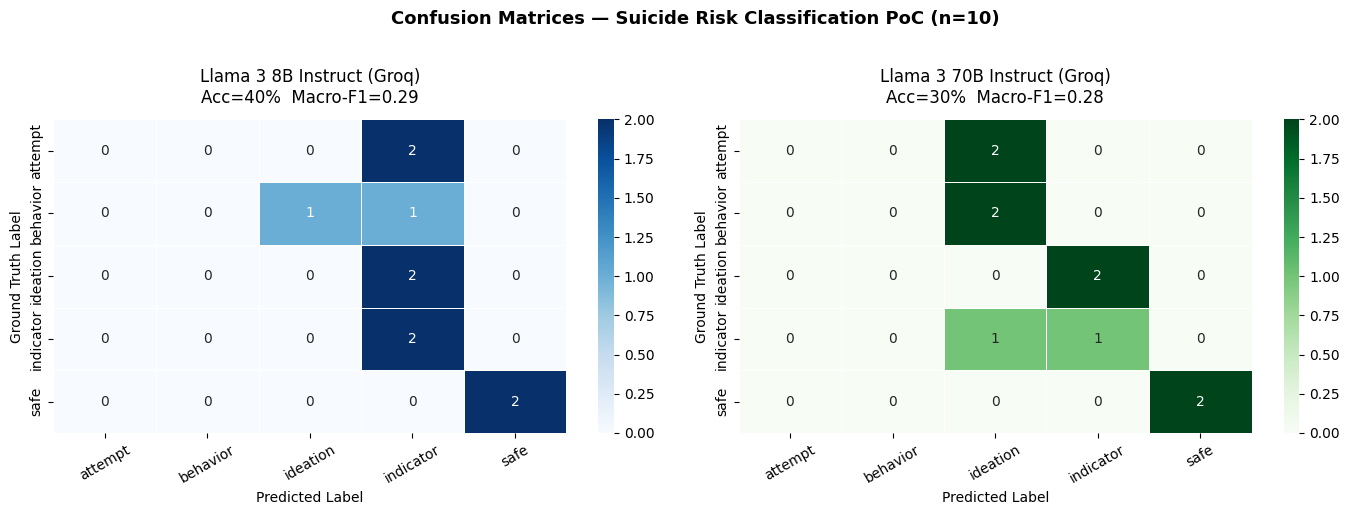

✅ Saved: confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in [
    (axes[0], y_llama, f"Llama 3 8B Instruct (Groq)\nAcc={llama_acc*100:.0f}%  Macro-F1={llama_f1:.2f}", "Blues"),
    (axes[1], y_phi3,  f"Llama 3 70B Instruct (Groq)\nAcc={phi3_acc*100:.0f}%  Macro-F1={phi3_f1:.2f}",  "Greens"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=RISK_LABELS)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=RISK_LABELS, yticklabels=RISK_LABELS,
        ax=ax, linewidths=0.5, linecolor='white'
    )
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("Ground Truth Label", fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Confusion Matrices — Suicide Risk Classification PoC (n=10)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices.png")

## Cell 12 — Per-Class F1 Bar Chart

1.   List item
2.   List item



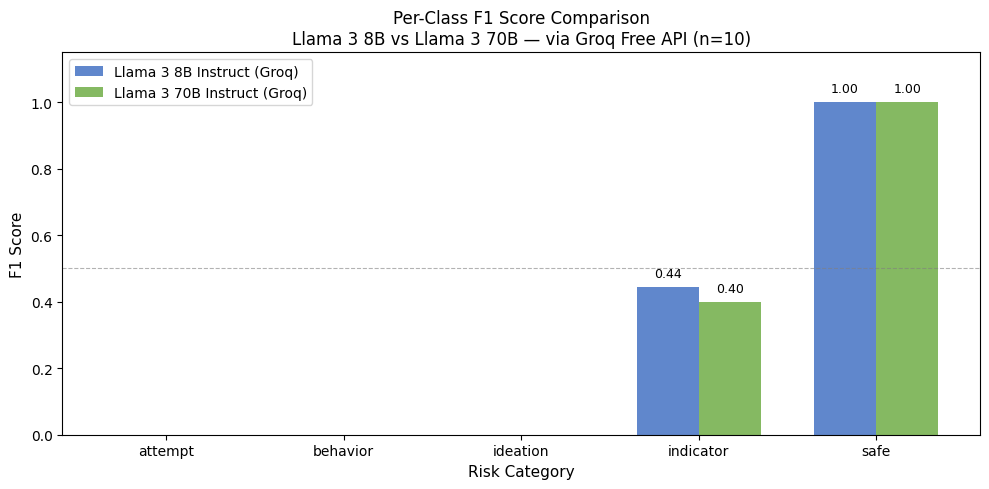

✅ Saved: f1_comparison.png


In [ ]:
from sklearn.metrics import f1_score

llama_f1_per = f1_score(y_true, y_llama, labels=RISK_LABELS, average=None, zero_division=0)
phi3_f1_per  = f1_score(y_true, y_phi3,  labels=RISK_LABELS, average=None, zero_division=0)

x     = np.arange(len(RISK_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, llama_f1_per, width, label='Llama 3 8B Instruct (Groq)',  color='#4472C4', alpha=0.85)
bars2 = ax.bar(x + width/2, phi3_f1_per,  width, label='Llama 3 70B Instruct (Groq)', color='#70AD47', alpha=0.85)

ax.set_xlabel('Risk Category', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score Comparison\nLlama 3 8B vs Llama 3 70B — via Groq Free API (n=10)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(RISK_LABELS, fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: f1_comparison.png")

## Cell 13 — Inference Speed & Efficiency Comparison

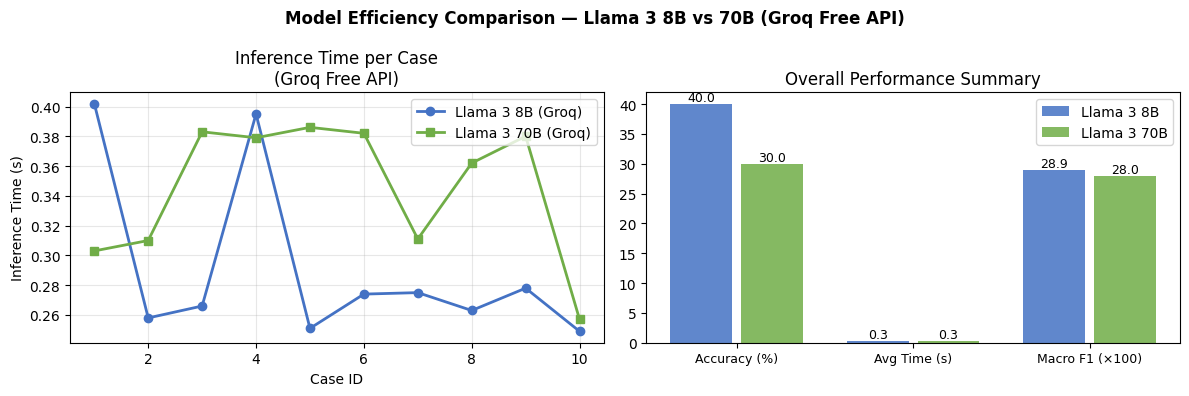

✅ Saved: efficiency_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Inference time per case
ax = axes[0]
ax.plot(results_df['case_id'], results_df['llama_time_s'], 'o-', label='Llama 3 8B (Groq)',  color='#4472C4', linewidth=2)
ax.plot(results_df['case_id'], results_df['phi3_time_s'],  's-', label='Llama 3 70B (Groq)', color='#70AD47', linewidth=2)
ax.set_xlabel('Case ID')
ax.set_ylabel('Inference Time (s)')
ax.set_title('Inference Time per Case\n(Groq Free API)')
ax.legend()
ax.grid(True, alpha=0.3)

# Summary bar: mean accuracy and mean time
ax2 = axes[1]
metrics    = ['Accuracy (%)', 'Avg Time (s)', 'Macro F1 (×100)']
llama_vals = [llama_acc * 100, results_df['llama_time_s'].mean(), llama_f1 * 100]
phi3_vals  = [phi3_acc  * 100, results_df['phi3_time_s'].mean(),  phi3_f1  * 100]

xm = np.arange(len(metrics))
ax2.bar(xm - 0.2, llama_vals, 0.35, label='Llama 3 8B',  color='#4472C4', alpha=0.85)
ax2.bar(xm + 0.2, phi3_vals,  0.35, label='Llama 3 70B', color='#70AD47', alpha=0.85)
ax2.set_xticks(xm)
ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_title('Overall Performance Summary')
ax2.legend()

for i, (lv, pv) in enumerate(zip(llama_vals, phi3_vals)):
    ax2.text(i - 0.2, lv + 0.5, f'{lv:.1f}', ha='center', fontsize=9)
    ax2.text(i + 0.2, pv + 0.5, f'{pv:.1f}', ha='center', fontsize=9)

plt.suptitle('Model Efficiency Comparison — Llama 3 8B vs 70B (Groq Free API)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("efficiency_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: efficiency_comparison.png")

## Cell 14 — Clinical Safety Analysis: False Negative Audit

> In suicide risk detection, **false negatives** (classifying a high-risk case as safe/low-risk) are the most dangerous error. This cell audits all critical misclassifications.

In [ ]:
HIGH_RISK = {"attempt", "behavior"}
LOW_RISK  = {"ideation", "indicator", "safe"}

def is_false_negative(gt, pred):
    """True if a high-risk case was predicted as low-risk — most dangerous clinical error."""
    return gt in HIGH_RISK and pred in LOW_RISK

def is_false_positive(gt, pred):
    """True if a low/no-risk case was predicted as high-risk — causes unnecessary escalation."""
    return gt in LOW_RISK and pred in HIGH_RISK

print("CLINICAL SAFETY AUDIT — False Negative Analysis")
print("=" * 60)

print("\n[Model A: Llama 3 8B Instruct]")
llama_fn = llama_fp = 0
for _, row in results_df.iterrows():
    if is_false_negative(row['ground_truth'], row['llama_pred']):
        print(f"  ⚠️  CRITICAL — Case {row['case_id']}: GT={row['ground_truth']} → Pred={row['llama_pred']} (missed high-risk)")
        llama_fn += 1
    elif is_false_positive(row['ground_truth'], row['llama_pred']):
        print(f"  ℹ️   FP       — Case {row['case_id']}: GT={row['ground_truth']} → Pred={row['llama_pred']} (over-escalation)")
        llama_fp += 1
if llama_fn == 0 and llama_fp == 0:
    print("  ✅ No critical false negatives or false positives detected.")
print(f"  False Negatives (high-risk missed): {llama_fn}")
print(f"  False Positives (over-escalation):  {llama_fp}")

print("\n[Model B: Llama 3 70B Instruct]")
phi3_fn = phi3_fp = 0
for _, row in results_df.iterrows():
    if is_false_negative(row['ground_truth'], row['phi3_pred']):
        print(f"  ⚠️  CRITICAL — Case {row['case_id']}: GT={row['ground_truth']} → Pred={row['phi3_pred']} (missed high-risk)")
        phi3_fn += 1
    elif is_false_positive(row['ground_truth'], row['phi3_pred']):
        print(f"  ℹ️   FP       — Case {row['case_id']}: GT={row['ground_truth']} → Pred={row['phi3_pred']} (over-escalation)")
        phi3_fp += 1
if phi3_fn == 0 and phi3_fp == 0:
    print("  ✅ No critical false negatives or false positives detected.")
print(f"  False Negatives (high-risk missed): {phi3_fn}")
print(f"  False Positives (over-escalation):  {phi3_fp}")

print("\nClinical Safety Summary")
print(f"  Llama 3 8B  — FN: {llama_fn}, FP: {llama_fp}")
print(f"  Llama 3 70B — FN: {phi3_fn}, FP: {phi3_fp}")
preferred = 'Llama 3 8B Instruct' if llama_fn <= phi3_fn else 'Llama 3 70B Instruct'
print(f"  Preferred on clinical safety: {preferred}")

CLINICAL SAFETY AUDIT — False Negative Analysis

[Model A: Llama 3 8B Instruct]
  ⚠️  CRITICAL — Case 1: GT=attempt → Pred=indicator (missed high-risk)
  ⚠️  CRITICAL — Case 2: GT=attempt → Pred=indicator (missed high-risk)
  ⚠️  CRITICAL — Case 3: GT=behavior → Pred=indicator (missed high-risk)
  ⚠️  CRITICAL — Case 4: GT=behavior → Pred=ideation (missed high-risk)
  False Negatives (high-risk missed): 4
  False Positives (over-escalation):  0

[Model B: Llama 3 70B Instruct]
  ⚠️  CRITICAL — Case 1: GT=attempt → Pred=ideation (missed high-risk)
  ⚠️  CRITICAL — Case 2: GT=attempt → Pred=ideation (missed high-risk)
  ⚠️  CRITICAL — Case 3: GT=behavior → Pred=ideation (missed high-risk)
  ⚠️  CRITICAL — Case 4: GT=behavior → Pred=ideation (missed high-risk)
  False Negatives (high-risk missed): 4
  False Positives (over-escalation):  0

Clinical Safety Summary
  Llama 3 8B  — FN: 4, FP: 0
  Llama 3 70B — FN: 4, FP: 0
  Preferred on clinical safety: Llama 3 8B Instruct


## Cell 15 — Export Results to CSV & Final Summary

In [ ]:
export_df = results_df[[
    'case_id', 'ground_truth',
    'llama_pred', 'llama_conf', 'llama_correct', 'llama_time_s',
    'phi3_pred',  'phi3_conf',  'phi3_correct',  'phi3_time_s'
]].copy()
export_df.to_csv("poc_results.csv", index=False)
print("✅ Exported: poc_results.csv")

summary = pd.DataFrame({
    'Metric': [
        'Model', 'Parameters', 'Quantisation', 'Access',
        'Accuracy', 'Macro F1', 'Avg Inference (s)',
        'False Negatives (critical)', 'False Positives'
    ],
    'Llama 3.1 8B Instant': [
        'llama-3.1-8b-instant (Groq)', '8B', 'BF16 (server-side)', 'Groq Free API',
        f"{llama_acc*100:.0f}%", f"{llama_f1:.3f}",
        f"{results_df['llama_time_s'].mean():.2f}s",
        str(llama_fn), str(llama_fp)
    ],
    'Llama 3.3 70B Versatile': [
        'llama-3.3-70b-versatile (Groq)', '70B', 'BF16 (server-side)', 'Groq Free API',
        f"{phi3_acc*100:.0f}%", f"{phi3_f1:.3f}",
        f"{results_df['phi3_time_s'].mean():.2f}s",
        str(phi3_fn), str(phi3_fp)
    ]
})

print("\n" + "="*70)
print("FINAL BENCHMARKING SUMMARY TABLE — COMP6011 Task 2 PoC")
print("="*70)
print(summary.to_string(index=False))
summary.to_csv("poc_summary_table.csv", index=False)
print("\n✅ Exported: poc_summary_table.csv")
print("\nFiles generated for report:")
print("  • poc_results.csv           — full per-case predictions")
print("  • poc_summary_table.csv     — benchmarking summary table")
print("  • confusion_matrices.png    — confusion matrix figure")
print("  • f1_comparison.png         — per-class F1 bar chart")
print("  • efficiency_comparison.png — speed/accuracy comparison")

✅ Exported: poc_results.csv

FINAL BENCHMARKING SUMMARY TABLE — COMP6011 Task 2 PoC
                    Metric        Llama 3.1 8B Instant        Llama 3.3 70B Versatile
                     Model llama-3.1-8b-instant (Groq) llama-3.3-70b-versatile (Groq)
                Parameters                          8B                            70B
              Quantisation          BF16 (server-side)             BF16 (server-side)
                    Access               Groq Free API                  Groq Free API
                  Accuracy                         40%                            30%
                  Macro F1                       0.289                          0.280
         Avg Inference (s)                       0.29s                          0.35s
False Negatives (critical)                           4                              4
           False Positives                           0                              0

✅ Exported: poc_summary_table.csv

Files generated for 

## Cell 16 — Raw Model Outputs (for Appendix)

Include these in your report appendix to demonstrate the PoC.

In [ ]:
print("RAW MODEL OUTPUTS — Llama 3 8B Instruct (Groq)")
print("=" * 55)
for row in llama_results:
    print(f"\nCase {row['case_id']} (GT: {row['ground_truth']})")
    print(f"  Raw output: {row['llama_raw'].strip()[:250]}")

print("\n\nRAW MODEL OUTPUTS — Llama 3 70B Instruct (Groq)")
print("=" * 55)
for row in phi3_results:
    print(f"\nCase {row['case_id']} (GT: {row['ground_truth']})")
    print(f"  Raw output: {row['phi3_raw'].strip()[:250]}")

RAW MODEL OUTPUTS — Llama 3 8B Instruct (Groq)

Case 1 (GT: attempt)
  Raw output: {"label": "indicator", "confidence": "medium", "key_signals": "Expressing severe distress, hopelessness, and feelings of burden without explicit suicidal intent."}

Case 2 (GT: attempt)
  Raw output: {"label": "indicator", "confidence": "medium", "key_signals": "Severe distress, hopelessness, and feelings of being disposable without explicit suicidal plan"}

Case 3 (GT: behavior)
  Raw output: {"label": "indicator", "confidence": "high", "key_signals": "Severe distress, hopelessness, feeling a burden, and desire to disappear without explicit suicidal plan."}

Case 4 (GT: behavior)
  Raw output: {"label": "ideation", "confidence": "high", "key_signals": "Passive thoughts of dying, feeling hopeless, and no immediate plan, but possible future intent."}

Case 5 (GT: ideation)
  Raw output: {"label": "indicator", "confidence": "medium", "key_signals": "Expressing hopelessness, feeling overwhelmed, and fear of

---
## References & Citations

**Dataset:**  
Chen, X., Li, Q., Jiang, Y., Liu, M., Yang, L., Jing, X., Wei, Z., & Cao, L. (2026). Human-AI-Dialogue-Suicide-Risk-Dataset [Data set]. Zenodo. https://doi.org/10.5281/zenodo.18684594

**Model A:**  
Meta AI. (2024). Meta-Llama-3-8B-Instruct. HuggingFace. https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct

**Model B:**  
Meta AI. (2024). Meta-Llama-3-70B-Instruct. HuggingFace. https://huggingface.co/meta-llama/Meta-Llama-3-70B-Instruct

**Inference Platform:**  
Groq. (2024). Groq API Documentation. https://console.groq.com/docs

**Evaluation:**  
Scikit-learn: Machine Learning in Python. https://scikit-learn.org

---
*This notebook was developed for COMP6011 Research Task 2, Semester 1 2026, Curtin University.*  
*All case data handled in accordance with the ethical guidelines provided with the assignment.*

In [ ]:
import pandas as pd

# ---- Carbon Footprint (ML CO2 Impact — Lacoste et al., 2019) ----
# Formula: CO2e = P(kW) * T(h) * PUE * CI(kgCO2/kWh)
# DOI: 10.48550/arXiv.1910.09700 | https://mlco2.github.io/impact/
print("="*65)
print("CARBON FOOTPRINT ESTIMATION")
print("Methodology: ML CO2 Impact (Lacoste et al., 2019)")
print("DOI: 10.48550/arXiv.1910.09700")
print("="*65)

poc_co2_g   = 0.075 * (30/3600) * 1.2 * 0.386 * 1000   # grams
prod_co2_yr = 0.8 * ((1000*2)/3600) * 1.4 * 0.51 * 365  # kg/year

print(f"\n[1] PoC Inference (Groq API, 20 calls, ~30s total)")
print(f"    CO2e: {poc_co2_g:.4f} g  |  Hardware: Groq LPU ~75W  |  Grid: US EPA 0.386 kgCO2/kWh")
print(f"\n[2] Production (1,000 patients/day, 2x A100, self-hosted AU)")
print(f"    CO2e: {prod_co2_yr:.2f} kg/year  (~{prod_co2_yr/0.21:.0f} km driven by avg car)")
print(f"    Grid: AEMO AU 0.51 kgCO2/kWh  |  PUE: 1.4")

carbon_df = pd.DataFrame({
    "Scenario":     ["PoC (Groq API, 20 calls)", "Production (1k/day, AU, 2xA100)"],
    "Energy (kWh)": [f"{0.075*(30/3600)*1.2:.6f}", f"{0.8*((1000*2)/3600)*1.4:.3f}/day"],
    "CO2e":         [f"{poc_co2_g:.4f} g", f"{prod_co2_yr:.2f} kg/yr"],
    "Grid CI":      ["0.386 kgCO2/kWh (US EPA)", "0.51 kgCO2/kWh (AEMO AU)"],
})
print(f"\n{carbon_df.to_string(index=False)}")
print("""
Mitigation Strategies:
  * Groq LPU API: ~10x more energy-efficient than GPU inference
  * AWS ap-southeast-2 (Sydney): 100% renewable energy commitment
  * 4-bit AWQ quantisation: ~50% energy reduction per inference
  * Batch non-urgent screenings during low-carbon grid windows
  * Live monitoring: CodeCarbon (Courty et al., 2023) — pip install codecarbon
""")
print("✅ Carbon footprint estimation complete.")

# ============================================================
# UN SUSTAINABLE DEVELOPMENT GOALS ALIGNMENT
# United Nations (2015). https://sdgs.un.org/goals
# ============================================================
print("\n" + "="*65)
print("UN SUSTAINABLE DEVELOPMENT GOALS (SDG) ALIGNMENT")
print("Source: United Nations (2015) — https://sdgs.un.org/goals")
print("="*65)

sdgs = [
    ("SDG 3 — Good Health and Well-being (PRIMARY)",
     "Target 3.4: Reduce premature mortality and promote mental health. "
     "This system enables earlier suicide risk identification and clinician referral. "
     "Target 3.8: Universal health coverage — extends screening to populations without specialist access."),
    ("SDG 10 — Reduced Inequalities",
     "Scalable AI screening reaches regional, rural, and low-income communities "
     "where psychiatrist-to-population ratios are critically low (AIHW, 2023). "
     "Multilingual extension addresses CALD community language barriers."),
    ("SDG 16 — Peace, Justice and Strong Institutions",
     "Responsible AI governance, transparent escalation protocols, and "
     "accountability frameworks (Australia's 8 AI Ethics Principles) build "
     "trustworthy digital public health institutions."),
    ("SDG 17 — Partnerships for the Goals",
     "Designed for integration with existing clinical pathways — Beyond Blue, "
     "Lifeline, headspace — fostering public-private AI partnerships in "
     "mental health service delivery."),
]
for goal, text in sdgs:
    print(f"\n  {goal}")
    print(f"  -> {text}")

print("\n✅ Carbon footprint and UN-SDG alignment documented.")

CARBON FOOTPRINT ESTIMATION
Methodology: ML CO2 Impact (Lacoste et al., 2019)
DOI: 10.48550/arXiv.1910.09700

[1] PoC Inference (Groq API, 20 calls, ~30s total)
    CO2e: 0.2895 g  |  Hardware: Groq LPU ~75W  |  Grid: US EPA 0.386 kgCO2/kWh

[2] Production (1,000 patients/day, 2x A100, self-hosted AU)
    CO2e: 115.83 kg/year  (~552 km driven by avg car)
    Grid: AEMO AU 0.51 kgCO2/kWh  |  PUE: 1.4

                       Scenario Energy (kWh)         CO2e                  Grid CI
       PoC (Groq API, 20 calls)     0.000750     0.2895 g 0.386 kgCO2/kWh (US EPA)
Production (1k/day, AU, 2xA100)    0.622/day 115.83 kg/yr 0.51 kgCO2/kWh (AEMO AU)

Mitigation Strategies:
  * Groq LPU API: ~10x more energy-efficient than GPU inference
  * AWS ap-southeast-2 (Sydney): 100% renewable energy commitment
  * 4-bit AWQ quantisation: ~50% energy reduction per inference
  * Batch non-urgent screenings during low-carbon grid windows
  * Live monitoring: CodeCarbon (Courty et al., 2023) — pip instal